In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.corpus import opinion_lexicon
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import numpy as np

# 1. Import data.

In [6]:
csv_paths = list(Path("../Dataset/data_new_approach/processed_data/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
new_preprocessed_lexicon.csv


In [8]:
file_path = csv_paths[0]
lexicon_df = pd.read_csv(file_path)
lexicon_df.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language
0,iOS,us,1.489512e+09,13976661175,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en
1,iOS,us,1.489512e+09,13968552342,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en
2,iOS,us,1.489512e+09,13965458699,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs,en
3,iOS,us,1.489512e+09,13963956841,2026-04-16 06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Easy peasy Very easy to use and efficient! Go...,11,Marcus By Goldman Sachs,en
4,iOS,us,1.489512e+09,13959051073,2026-04-14 19:38:27-07:00,tony ballognie,3,Needs widgets,I love the interface and how simple it is BUT ...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Needs widgets I love the interface and how sim...,25,Marcus By Goldman Sachs,en


# 2. Data Overview

In [9]:
lexicon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4478 entries, 0 to 4477
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   platform          4478 non-null   object 
 1   storefront        4478 non-null   object 
 2   app_id            2118 non-null   float64
 3   review_id         4478 non-null   object 
 4   date              2118 non-null   object 
 5   user              4478 non-null   object 
 6   rating            4478 non-null   int64  
 7   title             2118 non-null   object 
 8   review            4478 non-null   object 
 9   version           2118 non-null   object 
 10  package           2360 non-null   object 
 11  thumbsUpCount     2360 non-null   float64
 12  appVersion        2181 non-null   object 
 13  source_file       4478 non-null   object 
 14  raw_text          4478 non-null   object 
 15  raw_length_words  4478 non-null   int64  
 16  bank              4478 non-null   object 


In [10]:
# create a custom stopword list
custom_words = pd.DataFrame({
    "word": ["app", "bank", "banking", "mobile", "iphone", "apple", "android", "phone"],
    "lexicon": "custom"
})

default_stop_words = pd.DataFrame({
    "word": list(ENGLISH_STOP_WORDS),
    "lexicon": "sklearn"
})

custom_stop_words = pd.concat(
    [custom_words, default_stop_words],
    ignore_index=True
).drop_duplicates(subset=["word"])

# 3. Unigram Sentiment Analysis

## BING

In [11]:
# download Bing-style opinion lexicon
nltk.download("opinion_lexicon")

# Create Bing-style sentiment dataframe
positive_words = opinion_lexicon.positive()
negative_words = opinion_lexicon.negative()

bing = pd.DataFrame({
    "word": list(positive_words) + list(negative_words),
    "sentiment": ["positive"] * len(positive_words) + ["negative"] * len(negative_words)
})

# Create review-level dataframe and add a review ID before tokenization
# This is needed later for review-level sentiment scores.
df_english = lexicon_df.copy().reset_index(drop=True)
df_english["review_id"] = df_english.index

# Make sure tokenized reviews keep all original columns, including review_id
reviews_before_sw = df_english.copy()

reviews_before_sw["word"] = (
    reviews_before_sw["raw_text"]
    .fillna("")
    .str.lower()
    .str.findall(r"\b[a-z]+\b")
)

reviews_before_sw = reviews_before_sw.explode("word")
reviews_before_sw = reviews_before_sw.dropna(subset=["word"])

# Remove stopwords
reviews_after_sw = reviews_before_sw[
    ~reviews_before_sw["word"].isin(custom_stop_words["word"])
].copy()

# Inner join with Bing-style sentiment lexicon
bing_words = reviews_after_sw.merge(
    bing,
    on="word",
    how="inner"
)

bing_words.head()

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /Users/Khoai/nltk_data...
[nltk_data]   Unzipping corpora/opinion_lexicon.zip.


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language,word,sentiment
0,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,great,positive
1,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,easy,positive
2,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,best,positive
3,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,recommend,positive
4,iOS,us,1.489512e+09,2,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs,en,easy,positive


In [12]:
# Check that review_id was kept in the word-level dataframe
print(bing_words.columns.tolist())
bing_words[["bank", "platform", "review_id", "word", "sentiment"]].head()


['platform', 'storefront', 'app_id', 'review_id', 'date', 'user', 'rating', 'title', 'review', 'version', 'package', 'thumbsUpCount', 'appVersion', 'source_file', 'raw_text', 'raw_length_words', 'bank', 'language', 'word', 'sentiment']


,bank,platform,review_id,word,sentiment
0,Marcus By Goldman Sachs,iOS,1,great,positive
1,Marcus By Goldman Sachs,iOS,1,easy,positive
2,Marcus By Goldman Sachs,iOS,1,best,positive
3,Marcus By Goldman Sachs,iOS,1,recommend,positive
4,Marcus By Goldman Sachs,iOS,2,easy,positive


## Review sentiment distribution

In [13]:
# Review-level Bing sentiment distribution
# To compute review-level Bing sentiment, the sentiment score is calculated as:
# positive words - negative words.

bing_review = (
    bing_words
    .groupby(["bank", "platform", "review_id", "sentiment"])
    .size()
    .reset_index(name="n")
)

bing_review = (
    bing_review
    .pivot_table(
        index=["bank", "platform", "review_id"],
        columns="sentiment",
        values="n",
        fill_value=0
    )
    .reset_index()
)

bing_review.columns.name = None

# Make sure both columns exist even if one sentiment is absent in the data
if "positive" not in bing_review.columns:
    bing_review["positive"] = 0

if "negative" not in bing_review.columns:
    bing_review["negative"] = 0

bing_review["sentiment_score"] = (
    bing_review["positive"] - bing_review["negative"]
)

# Join the review-level sentiment score back to the review-level dataset
df_sent = df_english.merge(
    bing_review,
    on=["bank", "platform", "review_id"],
    how="left"
)

# Equivalent of summary(df_sent$sentiment_score) in R
print(df_sent["sentiment_score"].describe())
print("Missing values:", df_sent["sentiment_score"].isna().sum())

df_sent.head()

count    4050.000000
mean        0.915062
std         2.209947
min       -13.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        14.000000
Name: sentiment_score, dtype: float64
Missing values: 428


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,...,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language,negative,positive,sentiment_score
0,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,NaN,NaN,NaN
1,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,0.0,4.0,4.0
2,iOS,us,1.489512e+09,2,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs,en,0.0,4.0,4.0
3,iOS,us,1.489512e+09,3,2026-04-16 06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Easy peasy Very easy to use and efficient! Go...,11,Marcus By Goldman Sachs,en,0.0,4.0,4.0
4,iOS,us,1.489512e+09,4,2026-04-14 19:38:27-07:00,tony ballognie,3,Needs widgets,I love the interface and how simple it is BUT ...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Needs widgets I love the interface and how sim...,25,Marcus By Goldman Sachs,en,0.0,2.0,2.0


In [14]:
bing_words_sentiment_counts = (
    bing_words["sentiment"]
    .value_counts()
    .reset_index()
)

bing_words_sentiment_counts.columns = ["sentiment", "n"]

bing_words_sentiment_counts

,sentiment,n
0,positive,7363
1,negative,3657


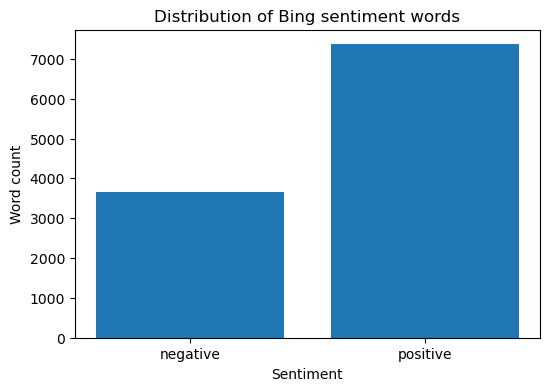

In [15]:
# count sentiment words
sentiment_counts = (
    bing_words
    .groupby("sentiment")
    .size()
    .reset_index(name="n")
)

# plot
plt.figure(figsize=(6, 4))

plt.bar(
    sentiment_counts["sentiment"],
    sentiment_counts["n"]
)

plt.title("Distribution of Bing sentiment words")
plt.xlabel("Sentiment")
plt.ylabel("Word count")

plt.show()

In [16]:
top_bing_words = (
    bing_words
    .groupby(["sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby("sentiment", group_keys=False)
    .head(10)
)

top_bing_words.head()

,sentiment,word,n
682,positive,easy,963
749,positive,great,666
798,positive,love,438
741,positive,good,379
793,positive,like,337


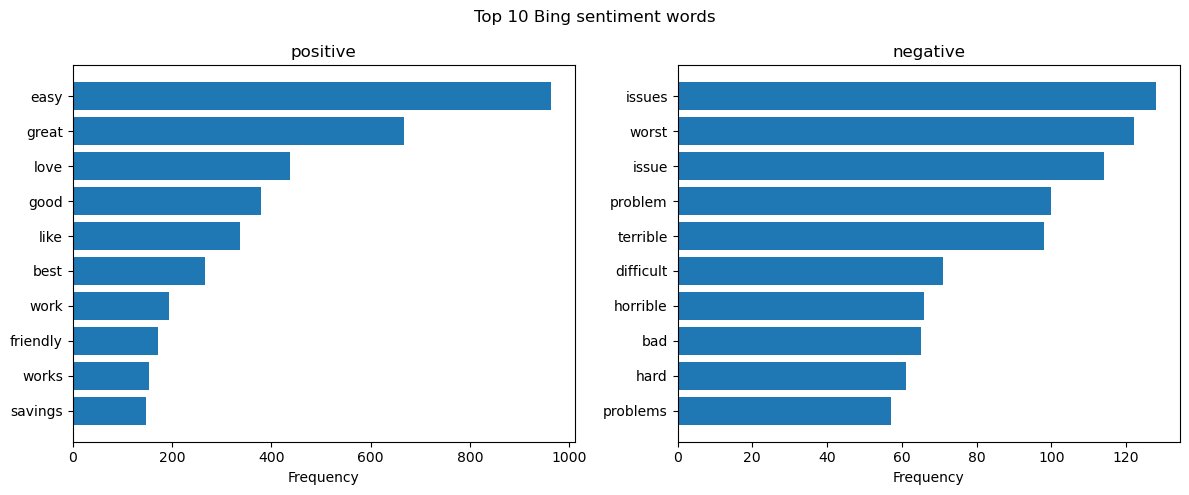

In [17]:
sentiments = top_bing_words["sentiment"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sentiments),
    figsize=(12, 5),
    sharex=False
)

if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sentiments):
    data = (
        top_bing_words[top_bing_words["sentiment"] == sentiment]
        .sort_values("n")
    )

    ax.barh(data["word"], data["n"])
    ax.set_title(sentiment)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

fig.suptitle("Top 10 Bing sentiment words")
plt.tight_layout()
plt.show()

In [18]:
bing_by_bank = (
    bing_words
    .groupby(["bank", "sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby(["bank", "sentiment"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

bing_by_bank.head()

,bank,sentiment,word,n
0,Citi,positive,easy,290
1,Marcus By Goldman Sachs,positive,easy,234
2,Marcus By Goldman Sachs,positive,great,172
3,Bank Of America,positive,easy,149
4,Chase,positive,easy,146


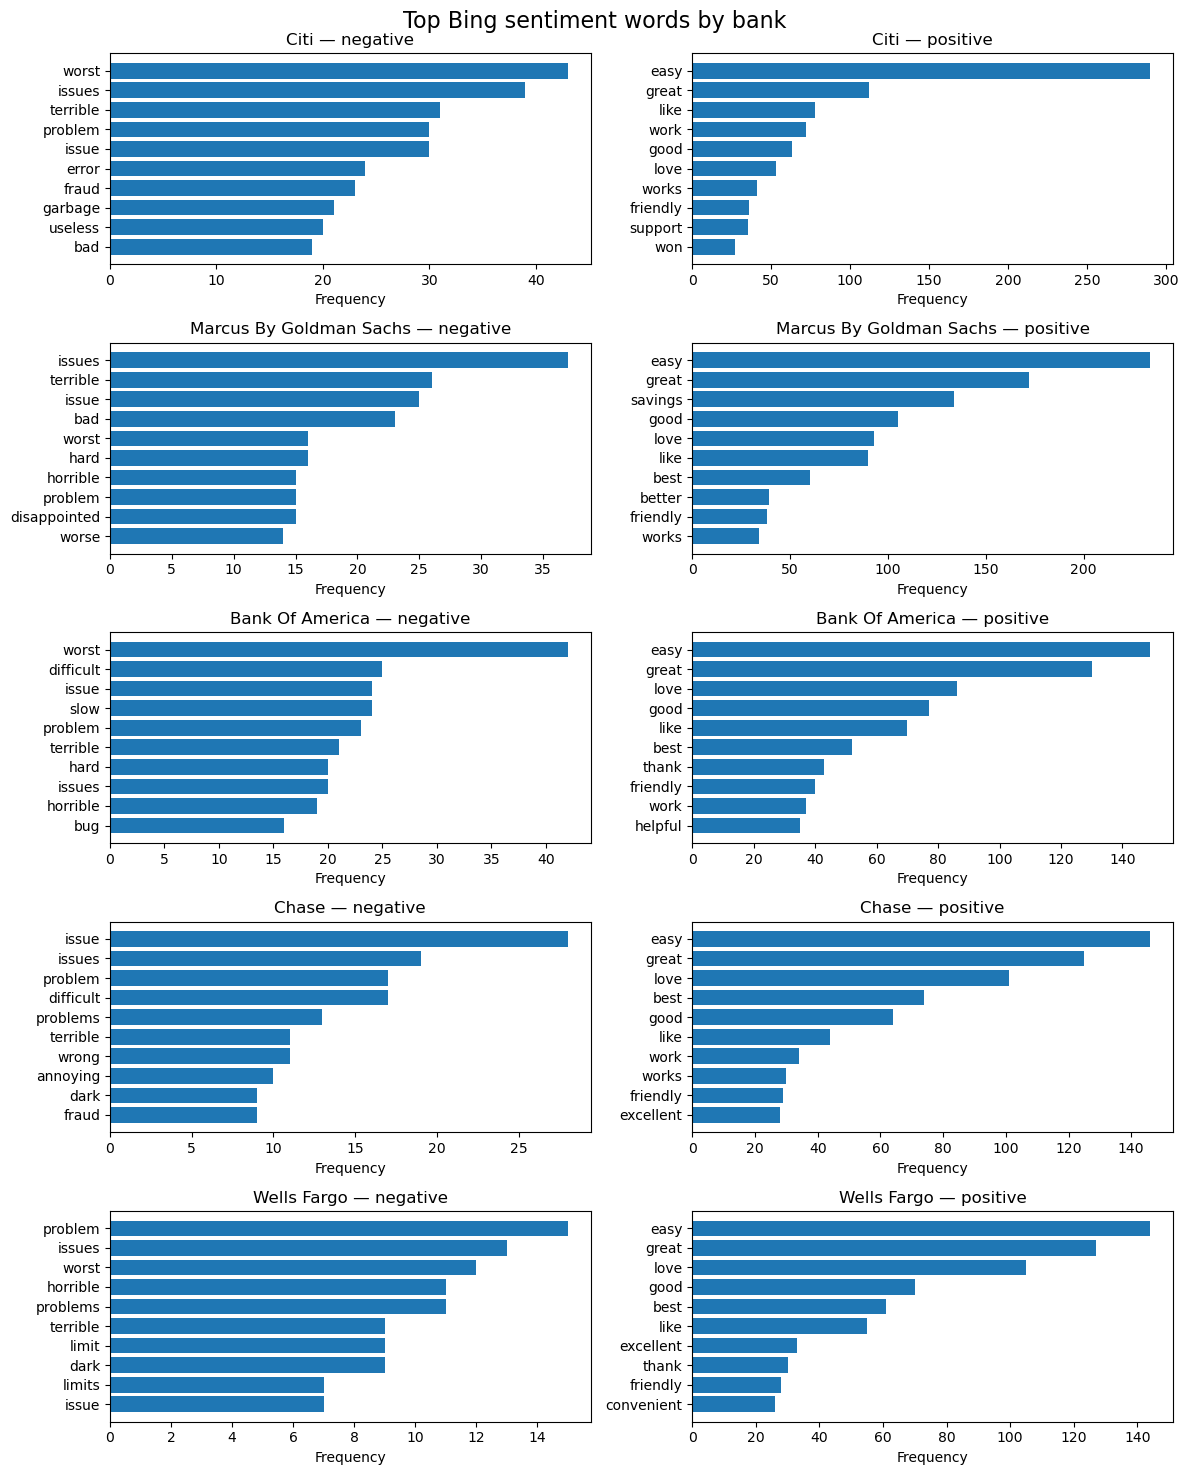

In [19]:
banks = bing_by_bank["bank"].drop_duplicates().tolist()
sentiments = ["negative", "positive"]

fig, axes = plt.subplots(
    nrows=len(banks),
    ncols=len(sentiments),
    figsize=(12, 3 * len(banks)),
    squeeze=False
)

for i, bank in enumerate(banks):
    for j, sentiment in enumerate(sentiments):
        ax = axes[i, j]

        data = (
            bing_by_bank[
                (bing_by_bank["bank"] == bank) &
                (bing_by_bank["sentiment"] == sentiment)
            ]
            .sort_values("n", ascending=True)
        )

        ax.barh(data["word"], data["n"])

        ax.set_title(f"{bank} — {sentiment}")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("")

        if data.empty:
            ax.axis("off")

fig.suptitle("Top Bing sentiment words by bank", fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
# sentiment words by platform
bing_by_platform = (
    bing_words
    .groupby(["platform", "sentiment", "word"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .groupby(["platform", "sentiment"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

bing_by_platform.head()

,platform,sentiment,word,n
0,Android,positive,easy,626
1,Android,positive,great,369
2,iOS,positive,easy,337
3,iOS,positive,great,297
4,iOS,positive,love,242


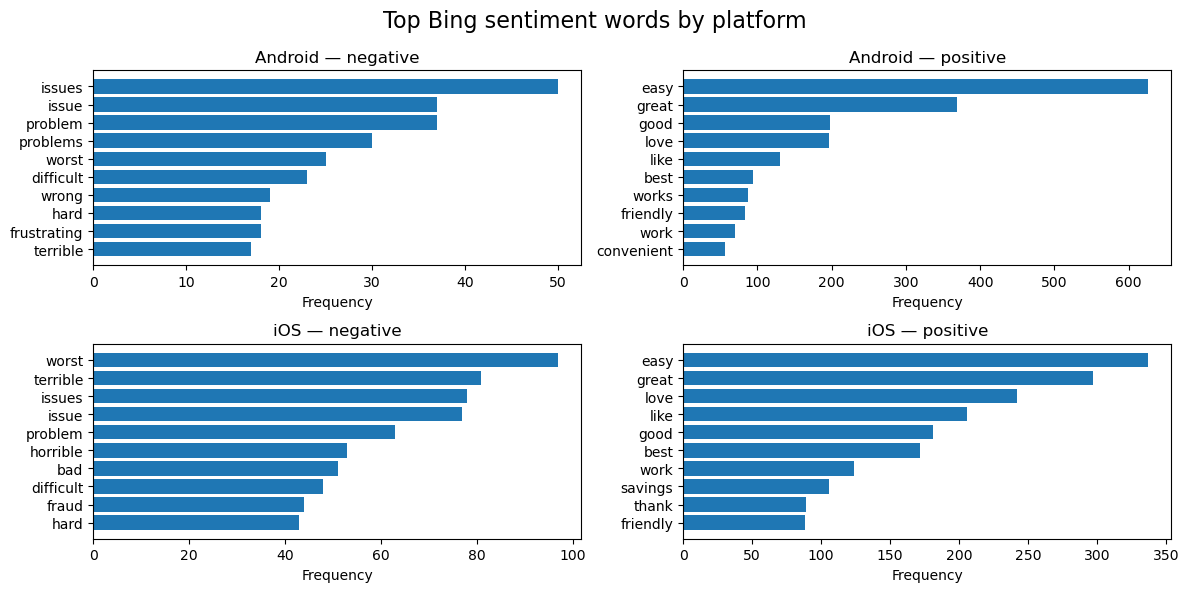

In [21]:
platforms = bing_by_platform["platform"].drop_duplicates().tolist()
sentiments = ["negative", "positive"]

fig, axes = plt.subplots(
    nrows=len(platforms),
    ncols=len(sentiments),
    figsize=(12, 3 * len(platforms)),
    squeeze=False
)

for i, platform in enumerate(platforms):
    for j, sentiment in enumerate(sentiments):
        ax = axes[i, j]

        data = (
            bing_by_platform[
                (bing_by_platform["platform"] == platform) &
                (bing_by_platform["sentiment"] == sentiment)
            ]
            .sort_values("n", ascending=True)
        )

        ax.barh(data["word"], data["n"])

        ax.set_title(f"{platform} — {sentiment}")
        ax.set_xlabel("Frequency")
        ax.set_ylabel("")

        if data.empty:
            ax.axis("off")

fig.suptitle("Top Bing sentiment words by platform", fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
bing_sentiment_pct = (
    bing_words
    .groupby(["bank", "platform", "sentiment"])
    .size()
    .reset_index(name="n")
)

bing_sentiment_pct["pct"] = (
    bing_sentiment_pct["n"] /
    bing_sentiment_pct.groupby(["bank", "platform"])["n"].transform("sum")
)

bing_sentiment_pct.head()

,bank,platform,sentiment,n,pct
0,Bank Of America,Android,negative,213,0.244828
1,Bank Of America,Android,positive,657,0.755172
2,Bank Of America,iOS,negative,604,0.459665
3,Bank Of America,iOS,positive,710,0.540335
4,Chase,Android,negative,235,0.307592


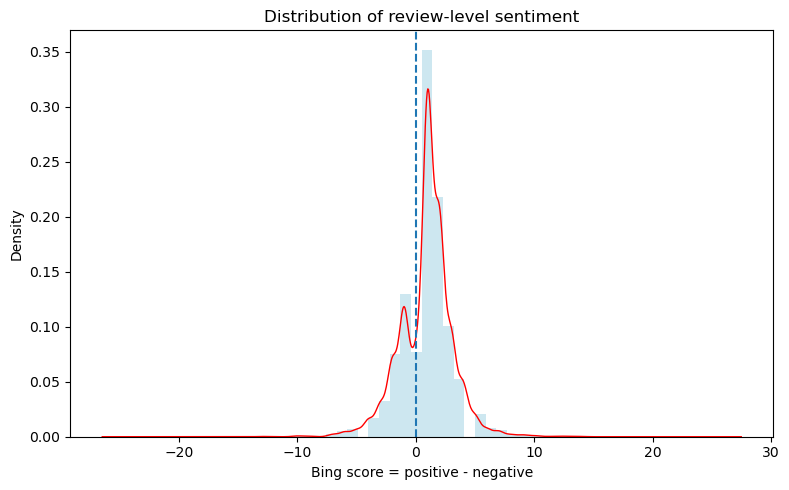

In [23]:
# Keep only finite sentiment scores
df_sent_plot = df_sent[np.isfinite(df_sent["sentiment_score"])].copy()

# Plot histogram + density curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_sent_plot["sentiment_score"],
    bins=30,
    density=True,
    color="lightblue",
    alpha=0.6
)

df_sent_plot["sentiment_score"].plot(
    kind="density",
    ax=ax,
    color="red",
    linewidth=1
)

ax.axvline(0, linestyle="--")

ax.set_title("Distribution of review-level sentiment")
ax.set_xlabel("Bing score = positive - negative")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

## Sentiment score and star ratings

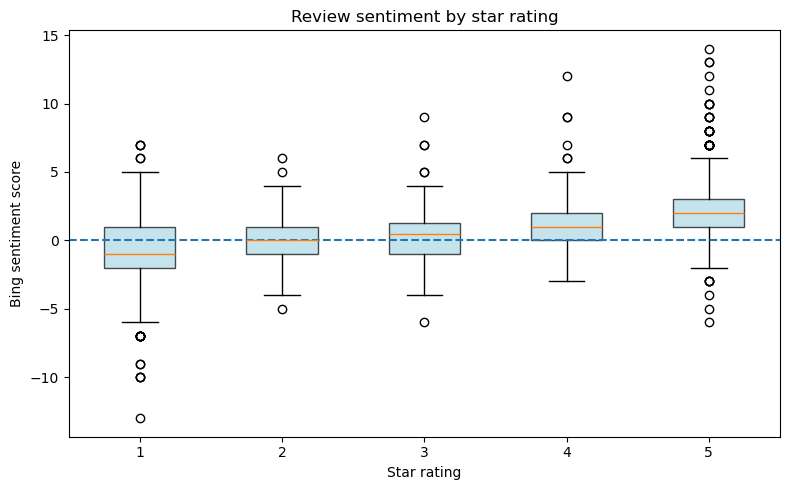

In [24]:
# Sentiment score and star ratings
# This plot shows whether the Bing sentiment score becomes more positive as star ratings increase.

rating_col = "rating"

if rating_col not in df_sent_plot.columns:
    raise KeyError(
        f"Column '{rating_col}' was not found. Available columns are: {df_sent_plot.columns.tolist()}"
    )

rating_plot = df_sent_plot.copy()
rating_plot[rating_col] = pd.to_numeric(rating_plot[rating_col], errors="coerce")
rating_plot["sentiment_score"] = pd.to_numeric(rating_plot["sentiment_score"], errors="coerce")

rating_plot = rating_plot.dropna(subset=[rating_col, "sentiment_score"])
rating_plot = rating_plot[np.isfinite(rating_plot["sentiment_score"])]

ratings = sorted(rating_plot[rating_col].unique())
box_data = [
    rating_plot.loc[rating_plot[rating_col] == rating, "sentiment_score"]
    for rating in ratings
]

rating_labels = [
    str(int(rating)) if float(rating).is_integer() else str(rating)
    for rating in ratings
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    box_data,
    labels=rating_labels,
    patch_artist=True
)

for patch in box["boxes"]:
    patch.set_facecolor("lightblue")
    patch.set_alpha(0.7)

ax.axhline(0, linestyle="--")

ax.set_title("Review sentiment by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Bing sentiment score")

plt.tight_layout()
plt.show()

## AFINN

In [25]:
local_afinn_path = Path("AFINN-111.txt")
afinn_url = "https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt"

if local_afinn_path.exists():
    afinn = pd.read_csv(
        local_afinn_path,
        sep="\t",
        names=["word", "value"]
    )
else:
    afinn = pd.read_csv(
        afinn_url,
        sep="\t",
        names=["word", "value"]
    )

afinn["word"] = afinn["word"].str.lower()
afinn["value"] = pd.to_numeric(afinn["value"], errors="coerce")

afinn.head()

,word,value
0,abandon,-2
1,abandoned,-2
2,abandons,-2
3,abducted,-2
4,abduction,-2


In [26]:
# Join AFINN scores to the tokenized review words
afinn_words = reviews_after_sw.merge(
    afinn,
    on="word",
    how="inner"
)

print("AFINN words:", len(afinn_words))
print("Bing words:", len(bing_words))

afinn_words.head()

AFINN words: 9634
Bing words: 11020


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language,word,value
0,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,great,3
1,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,easy,1
2,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,best,3
3,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,recommend,2
4,iOS,us,1.489512e+09,2,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs,en,easy,1


In [27]:
# Most frequent AFINN-scored words
top_afinn_words = (
    afinn_words
    .groupby(["word", "value"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_afinn_words

,word,value,n
0,easy,1,963
1,great,3,666
2,love,3,438
3,good,3,379
4,like,2,337
5,best,3,266
6,pay,-1,190
7,friendly,2,171
8,thank,2,142
9,want,1,138


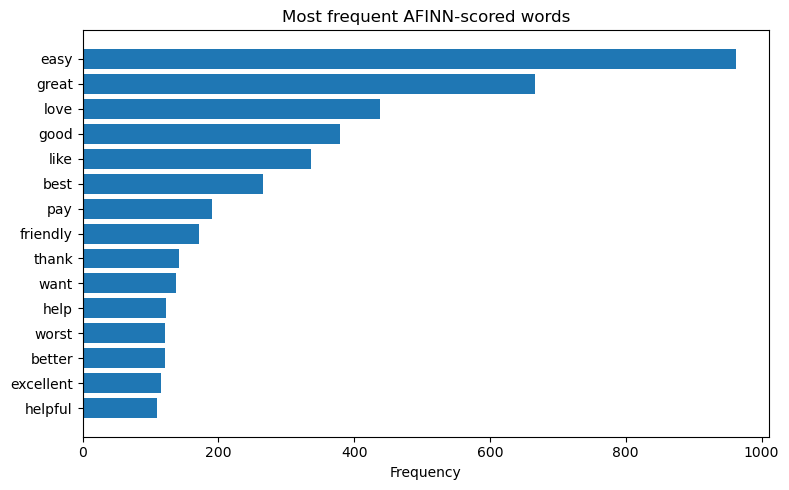

In [28]:
# Plot most frequent AFINN-scored words
plot_data = top_afinn_words.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(plot_data["word"], plot_data["n"])

ax.set_title("Most frequent AFINN-scored words")
ax.set_xlabel("Frequency")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Review-level AFINN sentiment

In [29]:
# Create the total AFINN score for each review and the mean AFINN score per review
afinn_review = (
    afinn_words
    .groupby(["bank", "platform", "review_id"])
    .agg(
        afinn_sum=("value", "sum"),
        afinn_mean=("value", "mean"),
        n_afinn=("value", "size")
    )
    .reset_index()
)

# Join review-level AFINN scores back to the review-level dataset
df_afinn = df_english.copy()
df_afinn["rating"] = pd.to_numeric(df_afinn["rating"], errors="coerce")

df_afinn = df_afinn.merge(
    afinn_review,
    on=["bank", "platform", "review_id"],
    how="left"
)

df_afinn.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,...,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language,afinn_sum,afinn_mean,n_afinn
0,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,NaN,NaN,NaN
1,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,9.0,2.250000,4.0
2,iOS,us,1.489512e+09,2,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs,en,4.0,1.333333,3.0
3,iOS,us,1.489512e+09,3,2026-04-16 06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Easy peasy Very easy to use and efficient! Go...,11,Marcus By Goldman Sachs,en,5.0,1.666667,3.0
4,iOS,us,1.489512e+09,4,2026-04-14 19:38:27-07:00,tony ballognie,3,Needs widgets,I love the interface and how simple it is BUT ...,2.20.0,...,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Needs widgets I love the interface and how sim...,25,Marcus By Goldman Sachs,en,6.0,2.000000,3.0


In [30]:
# How many reviews received an AFINN score?
afinn_scoring_summary = pd.DataFrame({
    "total_reviews": [len(df_afinn)],
    "scored_reviews": [df_afinn["afinn_sum"].notna().sum()],
    "pct_scored": [100 * df_afinn["afinn_sum"].notna().mean()]
})

afinn_scoring_summary

,total_reviews,scored_reviews,pct_scored
0,4478,3885,86.757481


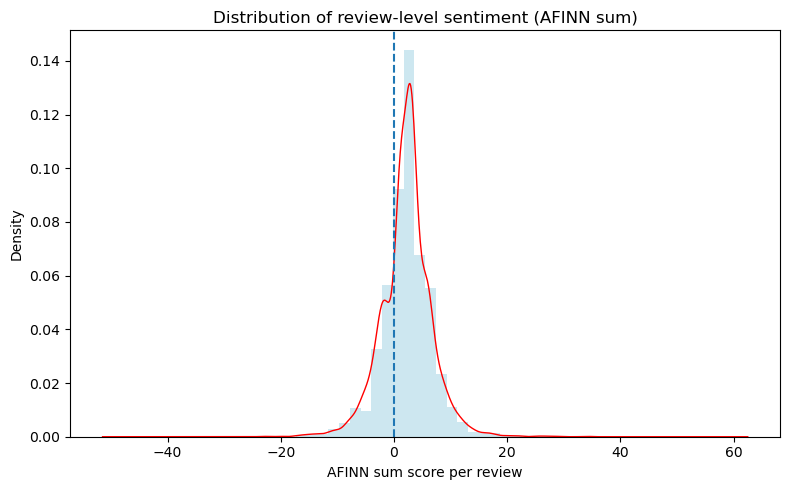

In [31]:
# Distribution of review-level AFINN sentiment
df_afinn_plot = df_afinn[np.isfinite(df_afinn["afinn_sum"])].copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_afinn_plot["afinn_sum"],
    bins=30,
    density=True,
    color="lightblue",
    alpha=0.6
)

df_afinn_plot["afinn_sum"].plot(
    kind="density",
    ax=ax,
    color="red",
    linewidth=1
)

ax.axvline(0, linestyle="--")

ax.set_title("Distribution of review-level sentiment (AFINN sum)")
ax.set_xlabel("AFINN sum score per review")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

AFINN sentiment by bank and platform

In [32]:
# How tone varies by bank and platform
afinn_bank_platform = (
    df_afinn
    .groupby(["bank", "platform"])
    .agg(
        mean_sum=("afinn_sum", "mean"),
        mean_mean=("afinn_mean", "mean"),
        n_reviews=("review_id", "size"),
        n_scored=("afinn_sum", lambda x: x.notna().sum())
    )
    .reset_index()
)

afinn_bank_platform

,bank,platform,mean_sum,mean_mean,n_reviews,n_scored
0,Bank Of America,Android,2.537037,1.455289,459,378
1,Bank Of America,iOS,1.482234,0.567137,453,394
2,Chase,Android,1.928382,1.165128,465,377
3,Chase,iOS,2.985591,1.267234,392,347
4,Citi,Android,2.622222,1.599498,489,450
5,Citi,iOS,-0.724051,-0.216243,470,395
6,Marcus By Goldman Sachs,Android,2.461538,1.341319,513,442
7,Marcus By Goldman Sachs,iOS,3.118182,0.983382,477,440
8,Wells Fargo,Android,2.183784,1.444061,434,370
9,Wells Fargo,iOS,3.804795,1.570727,326,292


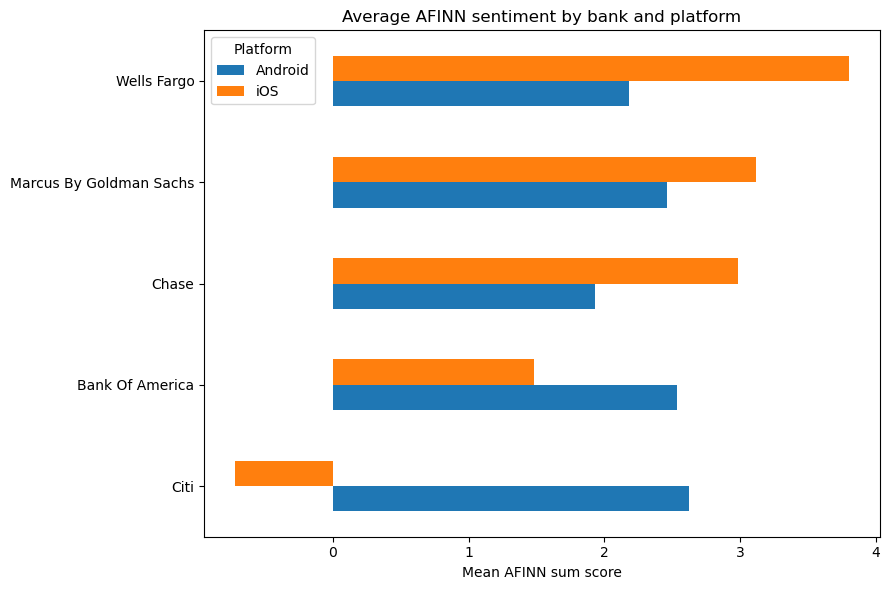

In [33]:
# Plot average AFINN sentiment by bank and platform
pivot_plot = afinn_bank_platform.pivot(
    index="bank",
    columns="platform",
    values="mean_sum"
)

# Order banks by the average AFINN score across platforms
bank_order = pivot_plot.mean(axis=1).sort_values().index
pivot_plot = pivot_plot.loc[bank_order]

fig, ax = plt.subplots(figsize=(9, 6))

pivot_plot.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Average AFINN sentiment by bank and platform")
ax.set_xlabel("Mean AFINN sum score")
ax.set_ylabel("")
ax.legend(title="Platform")

plt.tight_layout()
plt.show()

Top AFINN words by sentiment score

In [34]:
# Top AFINN sentiment words by score
top_afinn_by_score = (
    afinn_words
    .groupby(["value", "word"])
    .size()
    .reset_index(name="n")
    .sort_values(["value", "n"], ascending=[True, False])
    .groupby("value", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

top_afinn_by_score

,value,word,n
0,-4,fraud,55
1,-4,fraudulent,14
2,-4,hell,7
3,-4,damn,3
4,-4,fraudsters,1
...,...,...,...
75,4,fabulous,2
76,4,terrific,2
77,5,outstanding,14
78,5,superb,3


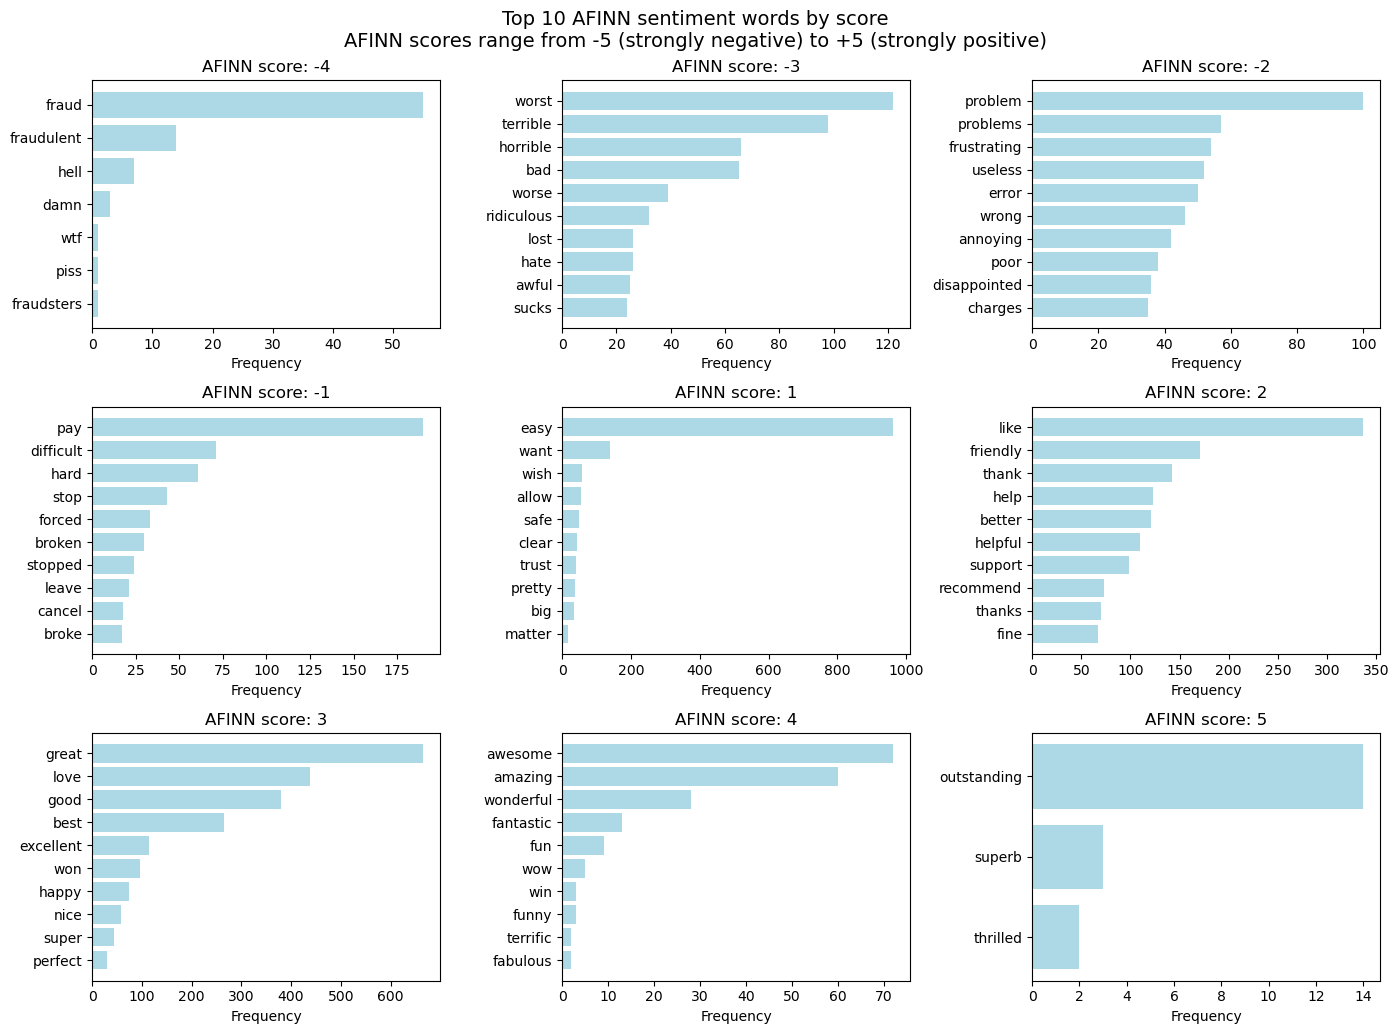

In [35]:
# Plot top AFINN words by score
import math

values = sorted(top_afinn_by_score["value"].dropna().unique())
ncols = 3
nrows = math.ceil(len(values) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 3.5 * nrows),
    squeeze=False
)

axes_flat = axes.flatten()

for ax, value in zip(axes_flat, values):
    data = (
        top_afinn_by_score[top_afinn_by_score["value"] == value]
        .sort_values("n", ascending=True)
    )
    
    ax.barh(data["word"], data["n"], color="lightblue")
    ax.set_title(f"AFINN score: {int(value)}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

for ax in axes_flat[len(values):]:
    ax.axis("off")

fig.suptitle(
    "Top 10 AFINN sentiment words by score\nAFINN scores range from -5 (strongly negative) to +5 (strongly positive)",
    fontsize=14
)

plt.tight_layout()
plt.show()

AFINN sentiment and star ratings

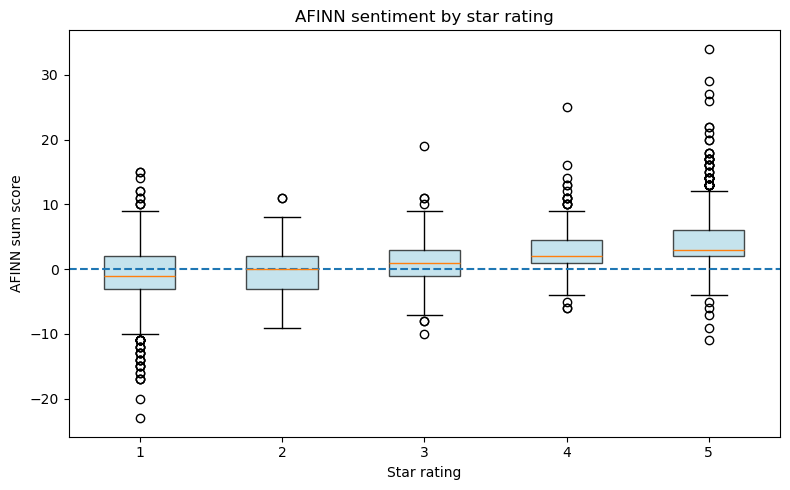

In [37]:
# AFINN sentiment by star rating
df_afinn_rating_plot = df_afinn.copy()
df_afinn_rating_plot["rating"] = pd.to_numeric(df_afinn_rating_plot["rating"], errors="coerce")
df_afinn_rating_plot["afinn_sum"] = pd.to_numeric(df_afinn_rating_plot["afinn_sum"], errors="coerce")

df_afinn_rating_plot = df_afinn_rating_plot.dropna(subset=["rating", "afinn_sum"])
df_afinn_rating_plot = df_afinn_rating_plot[np.isfinite(df_afinn_rating_plot["afinn_sum"])]

ratings = sorted(df_afinn_rating_plot["rating"].unique())
box_data = [
    df_afinn_rating_plot.loc[df_afinn_rating_plot["rating"] == rating, "afinn_sum"]
    for rating in ratings
]

rating_labels = [
    str(int(rating)) if float(rating).is_integer() else str(rating)
    for rating in ratings
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    box_data,
    labels=rating_labels,
    patch_artist=True
)

for patch in box["boxes"]:
    patch.set_facecolor("lightblue")
    patch.set_alpha(0.7)

ax.axhline(0, linestyle="--")

ax.set_title("AFINN sentiment by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("AFINN sum score")

plt.tight_layout()
plt.show()

In [38]:
# Pearson correlation between star rating and AFINN sum score
from scipy.stats import pearsonr

cor_data = df_afinn_rating_plot[["rating", "afinn_sum"]].dropna()

if len(cor_data) >= 3:
    r, p_value = pearsonr(cor_data["rating"], cor_data["afinn_sum"])
    n = len(cor_data)
    
    # Approximate 95% confidence interval using Fisher z-transformation
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.96
    ci_low, ci_high = np.tanh([z - z_crit * se, z + z_crit * se])
    
    print("Pearson correlation test")
    print(f"n = {n}")
    print(f"correlation = {r:.4f}")
    print(f"p-value = {p_value:.4g}")
    print(f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")
else:
    print("Not enough complete observations for correlation test.")

Pearson correlation test
n = 3885
correlation = 0.5387
p-value = 2.155e-291
95% CI = [0.5160, 0.5607]


## NRC

The NRC lexicon assigns words to several emotion categories. One word can belong to more than one category, so the join is expected to create multiple rows for some words.

In [42]:
import urllib.request
from pathlib import Path

nrc_path = Path("../Dataset/nrc_lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt")
nrc_path.parent.mkdir(parents=True, exist_ok=True)

if not nrc_path.exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/dinbav/LeXmo/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt",
        nrc_path
    )

nrc = pd.read_csv(
    nrc_path,
    sep="\t",
    names=["word", "sentiment", "association"]
)

# keep only words that are actually associated with an emotion/sentiment
nrc = nrc[nrc["association"] == 1].copy()
nrc = nrc[["word", "sentiment"]]
nrc["word"] = nrc["word"].str.lower()

nrc.head()

,word,sentiment
19,abacus,trust
23,abandon,fear
25,abandon,negative
27,abandon,sadness
30,abandoned,anger


In [43]:
# Join NRC categories to the tokenized review words
# This is a many-to-many relationship because one word can match several NRC categories.

nrc_words = reviews_after_sw.merge(
    nrc,
    on="word",
    how="inner"
)

print("NRC words:", len(nrc_words))
print("Total tokens after stopword removal:", len(reviews_after_sw))

nrc_words.head()

NRC words: 27870
Total tokens after stopword removal: 53094


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language,word,sentiment
0,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,option,positive
1,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,recommend,positive
2,iOS,us,1.489512e+09,1,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs,en,recommend,trust
3,iOS,us,1.489512e+09,2,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs,en,account,trust
4,iOS,us,1.489512e+09,2,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs,en,worth,positive


In [44]:
# Overview of NRC emotion category counts
nrc_counts = (
    nrc_words
    .groupby("sentiment")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

nrc_counts

,sentiment,n
0,positive,6941
1,trust,5281
2,negative,3280
3,anticipation,2981
4,joy,2954
5,anger,1506
6,sadness,1409
7,surprise,1348
8,fear,1347
9,disgust,823


In [45]:
# NRC token coverage
nrc_coverage = pd.DataFrame({
    "total_tokens": [len(reviews_after_sw)],
    "nrc_tokens": [len(nrc_words)],
    "pct_covered": [100 * len(nrc_words) / len(reviews_after_sw)]
})

nrc_coverage

,total_tokens,nrc_tokens,pct_covered
0,53094,27870,52.491807


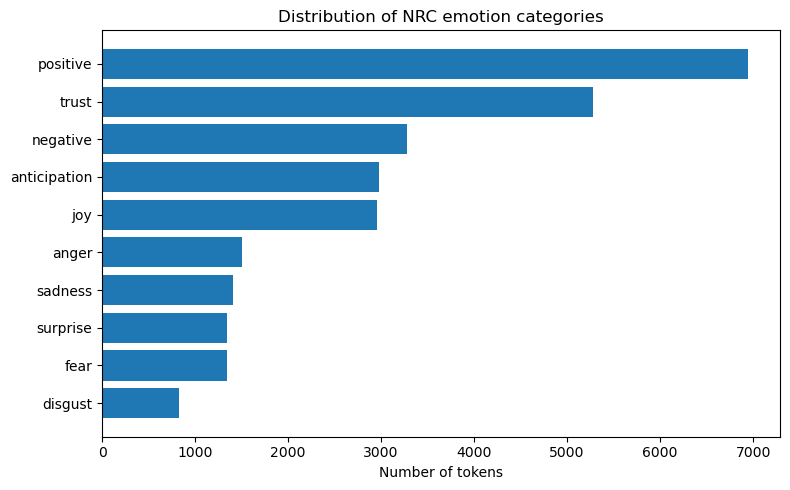

In [46]:
# Plot distribution of NRC emotion categories
plot_data = nrc_counts.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(plot_data["sentiment"], plot_data["n"])

ax.set_title("Distribution of NRC emotion categories")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## NRC emotion composition by bank

In [47]:
# NRC emotion by bank
nrc_by_bank = (
    nrc_words
    .groupby(["bank", "sentiment"])
    .size()
    .reset_index(name="n")
)

nrc_by_bank["pct"] = (
    nrc_by_bank["n"] /
    nrc_by_bank.groupby("bank")["n"].transform("sum")
)

nrc_by_bank

,bank,sentiment,n,pct
0,Bank Of America,anger,256,0.049478
1,Bank Of America,anticipation,555,0.107267
2,Bank Of America,disgust,180,0.034789
3,Bank Of America,fear,287,0.055470
4,Bank Of America,joy,548,0.105914
5,Bank Of America,negative,623,0.120410
6,Bank Of America,positive,1306,0.252416
7,Bank Of America,sadness,278,0.053730
8,Bank Of America,surprise,208,0.040201
9,Bank Of America,trust,933,0.180325


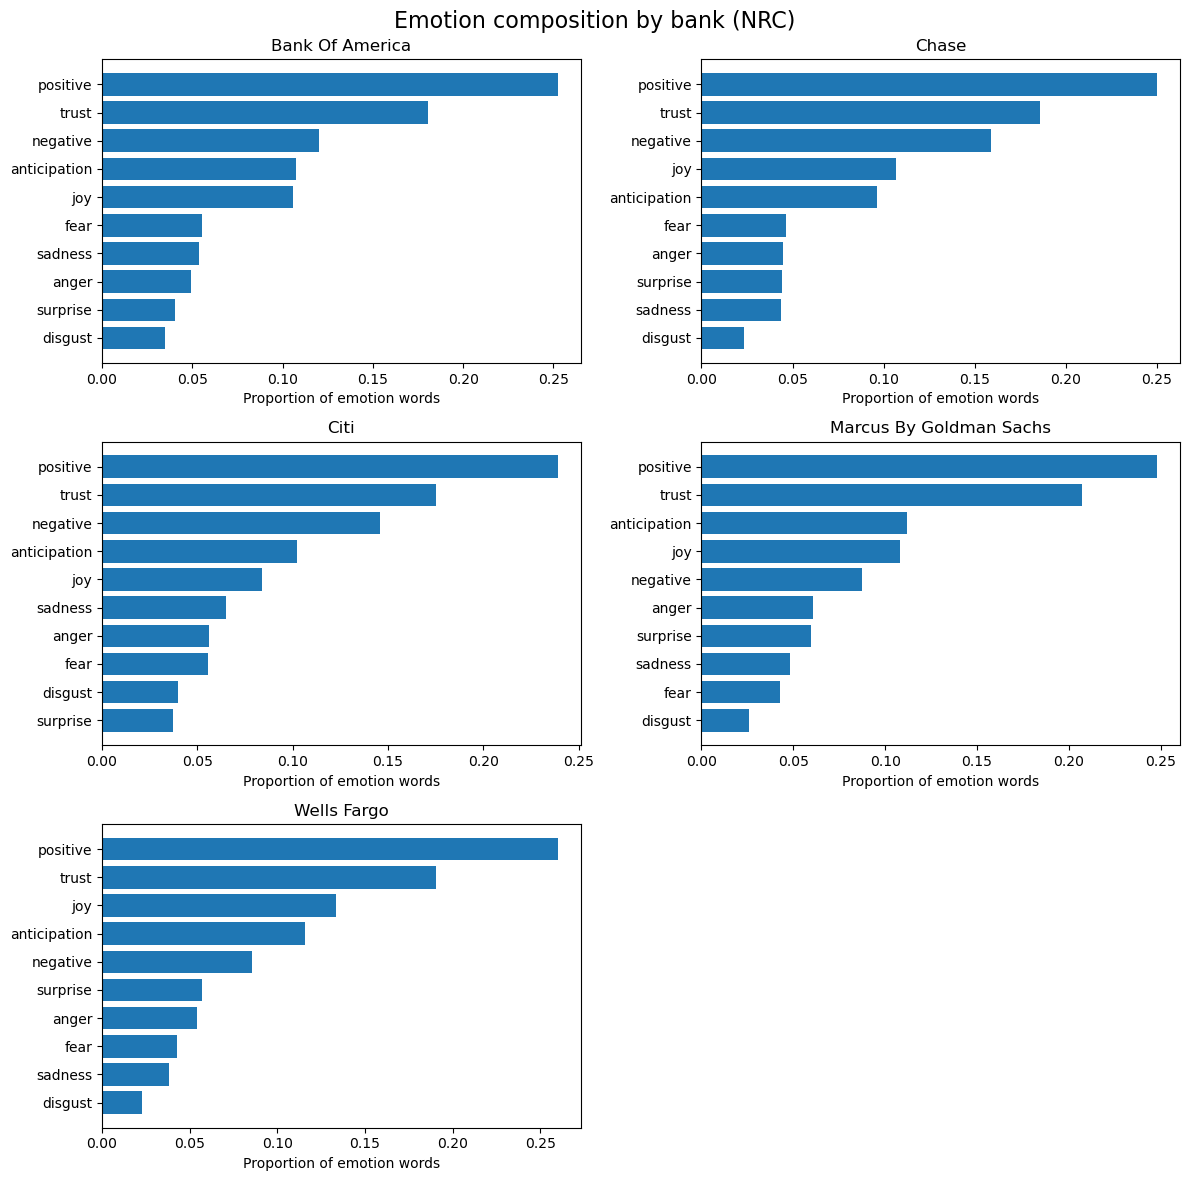

In [48]:
# Plot emotion composition by bank
banks = sorted(nrc_by_bank["bank"].unique())
n_cols = 2
n_rows = int(np.ceil(len(banks) / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(12, 4 * n_rows),
    squeeze=False
)

for i, bank in enumerate(banks):
    ax = axes[i // n_cols, i % n_cols]
    data = (
        nrc_by_bank[nrc_by_bank["bank"] == bank]
        .sort_values("pct", ascending=True)
    )

    ax.barh(data["sentiment"], data["pct"])
    ax.set_title(bank)
    ax.set_xlabel("Proportion of emotion words")
    ax.set_ylabel("")

# Hide unused subplot panels, if any
for j in range(len(banks), n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")

fig.suptitle("Emotion composition by bank (NRC)", fontsize=16)
plt.tight_layout()
plt.show()

## NRC emotion composition by platform

In [49]:
# NRC emotion by platform
nrc_by_platform = (
    nrc_words
    .groupby(["platform", "sentiment"])
    .size()
    .reset_index(name="n")
)

nrc_by_platform["pct"] = (
    nrc_by_platform["n"] /
    nrc_by_platform.groupby("platform")["n"].transform("sum")
)

nrc_by_platform

,platform,sentiment,n,pct
0,Android,anger,434,0.045143
1,Android,anticipation,1093,0.113688
2,Android,disgust,204,0.021219
3,Android,fear,370,0.038486
4,Android,joy,1179,0.122634
5,Android,negative,944,0.098190
6,Android,positive,2588,0.269191
7,Android,sadness,368,0.038278
8,Android,surprise,503,0.052320
9,Android,trust,1931,0.200853


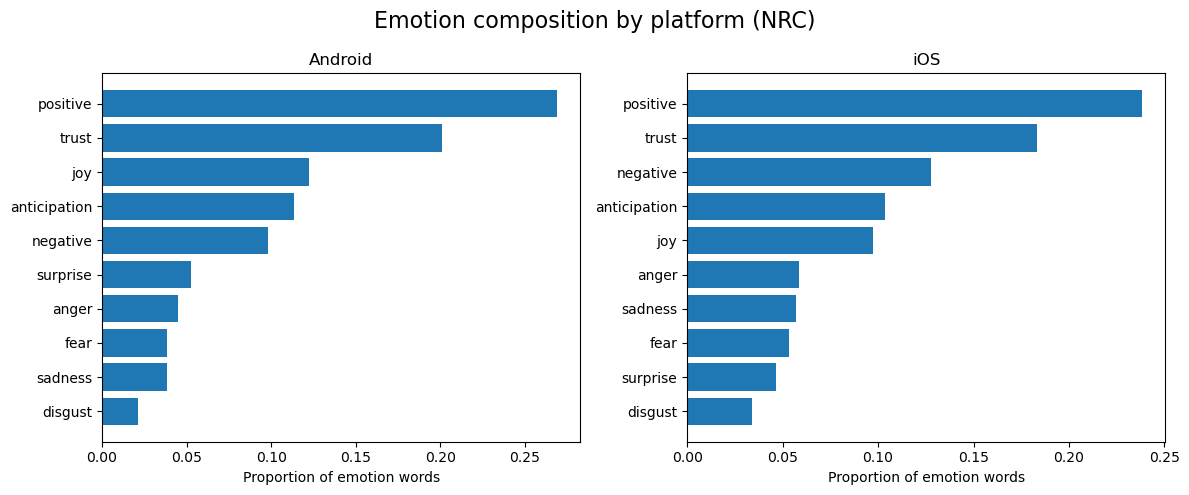

In [50]:
# Plot emotion composition by platform
platforms = sorted(nrc_by_platform["platform"].unique())

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(6 * len(platforms), 5),
    squeeze=False
)

for i, platform in enumerate(platforms):
    ax = axes[0, i]
    data = (
        nrc_by_platform[nrc_by_platform["platform"] == platform]
        .sort_values("pct", ascending=True)
    )

    ax.barh(data["sentiment"], data["pct"])
    ax.set_title(platform)
    ax.set_xlabel("Proportion of emotion words")
    ax.set_ylabel("")

fig.suptitle("Emotion composition by platform (NRC)", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Bigrams Analysis

In [51]:
# Create bigrams from the original review text
# This keeps review-level metadata such as bank, platform, review_id, and rating.

import re

# Negation words are kept, because they are important for interpreting sentiment.
negators = {
    "no", "not", "nor", "never", "none", "neither", "cannot",
    "hardly", "rarely", "barely", "n't", "dont", "don't", "isn't", "wasn't",
    "aren't", "won't", "shouldn't", "couldn't", "wouldn't", "doesn't",
    "didn't", "haven't", "hasn't", "hadn't", "can't", "cant"
}

# Use the existing stopword list, but do not remove negators.
custom_stop_words_bigram = set(custom_stop_words["word"]) - negators


def make_bigrams(text):
    """Clean text and return adjacent word pairs."""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    return list(zip(words[:-1], words[1:]))


bigram_records = []

for _, row in df_english.iterrows():
    pairs = make_bigrams(row.get("raw_text", ""))
    if not pairs:
        continue

    base = row.to_dict()
    for word1, word2 in pairs:
        bigram_records.append({
            **base,
            "word1": word1,
            "word2": word2
        })

bigrams = pd.DataFrame(bigram_records)

# Remove stopwords from both positions, while keeping negators.
bigrams = bigrams[
    (~bigrams["word1"].isin(custom_stop_words_bigram)) &
    (~bigrams["word2"].isin(custom_stop_words_bigram))
].copy()

bigrams.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank,language,word1,word2
0,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,no,atm
1,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,atm,option
2,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,option,no
3,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,no,debit
4,iOS,us,1.489512e+09,0,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs,en,debit,card


In [52]:
# Count most frequent bigrams
bigram_counts = (
    bigrams
    .groupby(["word1", "word2"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

bigram_counts.head(20)

,word1,word2,n
0,customer,service,222
1,don,t,196
2,wells,fargo,177
3,credit,card,151
4,user,friendly,117
5,doesn,t,101
6,does,not,74
7,no,longer,66
8,won,t,56
9,savings,account,55


## Quantifying negation effect

In [53]:
# Identify bigrams where the first word is a negator and the second word has an AFINN score.
# The negated value reverses the original AFINN score.

negated_afinn = (
    bigrams[bigrams["word1"].isin(negators)]
    .merge(
        afinn,
        left_on="word2",
        right_on="word",
        how="inner"
    )
    .copy()
)

negated_afinn["negated_value"] = -negated_afinn["value"]

negation_by_bigram = (
    negated_afinn
    .groupby(["word1", "word2"])
    .agg(
        original_value=("value", "mean"),
        negated_value=("negated_value", "mean"),
        n_occurrences=("word2", "size")
    )
    .reset_index()
    .sort_values("n_occurrences", ascending=False)
    .reset_index(drop=True)
)

negation_by_bigram.head(20)

,word1,word2,original_value,negated_value,n_occurrences
0,no,problems,-2.0,2.0,16
1,not,allow,1.0,-1.0,15
2,not,happy,3.0,-3.0,12
3,no,problem,-2.0,2.0,11
4,no,help,2.0,-2.0,10
5,not,helpful,2.0,-2.0,9
6,not,recommend,2.0,-2.0,9
7,don't,like,2.0,-2.0,8
8,no,matter,1.0,-1.0,8
9,no,good,3.0,-3.0,8


In [54]:
# Quantify the size of the negation correction by star rating.

negated_afinn["rating"] = pd.to_numeric(negated_afinn["rating"], errors="coerce")
negated_afinn_rating = negated_afinn.dropna(subset=["rating"]).copy()

neg_by_rating = (
    negated_afinn_rating
    .groupby("rating")
    .agg(
        total_negation_shift=("negated_value", "sum"),
        mean_negation_shift=("negated_value", "mean"),
        n_negated_bigrams=("negated_value", "size")
    )
    .reset_index()
)

reviews_per_rating = (
    df_english
    .assign(rating=pd.to_numeric(df_english["rating"], errors="coerce"))
    .dropna(subset=["rating"])
    .groupby("rating")
    .size()
    .reset_index(name="n_reviews")
)

negation_by_rating_norm = neg_by_rating.merge(
    reviews_per_rating,
    on="rating",
    how="left"
)

negation_by_rating_norm["negation_shift_per_review"] = (
    negation_by_rating_norm["total_negation_shift"] /
    negation_by_rating_norm["n_reviews"]
)

negation_by_rating_norm["negated_bigrams_per_review"] = (
    negation_by_rating_norm["n_negated_bigrams"] /
    negation_by_rating_norm["n_reviews"]
)

negation_by_rating_norm

,rating,total_negation_shift,mean_negation_shift,n_negated_bigrams,n_reviews,negation_shift_per_review,negated_bigrams_per_review
0,1,-216,-1.107692,195,1319,-0.163760,0.147839
1,2,-30,-1.200000,25,241,-0.124481,0.103734
2,3,-36,-1.500000,24,220,-0.163636,0.109091
3,4,-4,-0.222222,18,275,-0.014545,0.065455
4,5,63,1.211538,52,2423,0.026001,0.021461


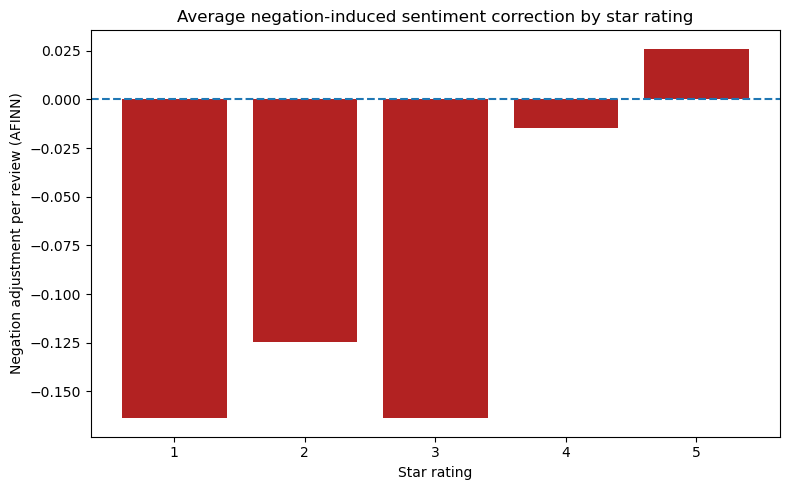

In [55]:
# Plot average negation-induced sentiment correction by star rating
plot_data = negation_by_rating_norm.sort_values("rating").copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    plot_data["rating"].astype(str),
    plot_data["negation_shift_per_review"],
    color="firebrick"
)

ax.axhline(0, linestyle="--")

ax.set_title("Average negation-induced sentiment correction by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Negation adjustment per review (AFINN)")

plt.tight_layout()
plt.show()

# 5. Transformer Based Sentiment Analysis